In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import importlib
import pandas as pd
import os

from modules import Autoencoder, MINE
importlib.reload(Autoencoder)  # 모듈 갱신
from torch.utils.tensorboard import SummaryWriter

DIGITS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # 학습할 숫자들 설정
DIGITS_STR = ''.join(map(str, DIGITS))
latent_dim = 16
epochs = 100
autoencoder_lr = 0.0001

# 모델 초기화
autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
optimizer = optim.Adam(autoencoder.parameters(), lr=autoencoder_lr)
criterion = nn.MSELoss()

mine_lr = 0.001
coeff = 0.001 #이게 너무 높으면 안됨.
# 대략 mi는 0~10 스케일, recon은 0.01~0.02 스케일이므로 0.0005 스케일로 설정하자. 0.002였을땐 후반에 꺾였음..
# Mutual Information Estimator 초기화
mi_estimator = MINE.LinearMine(code_qubits=28 * 28, output_dim=latent_dim,size=64)
mi_optimizer = optim.Adam(mi_estimator.parameters(), lr=mine_lr)

# 데이터 로더 설정 (DIGITS 필터 적용)
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
filtered_data = [(img, label) for img, label in train_data if label in DIGITS]
train_loader = DataLoader(filtered_data, batch_size=64, shuffle=True)

log_dir = f"runs/InfomaxEncoder_{DIGITS_STR}_{latent_dim}_ep{epochs}_lr{autoencoder_lr}_mi_lr{mine_lr}_coeff{coeff}"
os.makedirs(log_dir, exist_ok=True)
writer = SummaryWriter(log_dir=log_dir)  # TensorBoard writer 초기화
csv_path = os.path.join(log_dir, f"InfomaxEncoder_{DIGITS_STR}_{latent_dim}_ep{epochs}_lr{autoencoder_lr}.csv")

# 오토인코더 학습
losses = {"recon_loss": [], "mi_loss": [], "total_loss": []}  # 손실 기록
for epoch in range(epochs):
    epoch_recon_loss = 0
    epoch_mi_loss = 0
    epoch_total_loss = 0
    batch_count = 0
    latent_vectors = {digit: [] for digit in DIGITS}  # 각 숫자의 latent 벡터 저장. 이후 시각화에 사용.

    debug_pred_x_y = 0

    for images, labels in train_loader:
        images = images.view(-1, 1, 28, 28)
        optimizer.zero_grad()
        mi_optimizer.zero_grad()

        reconstructed, latent = autoencoder(images) # 이미지 압축
        for i, label in enumerate(labels):
            if label in DIGITS:
                latent_vectors[label.item()].append(latent[i].detach().cpu().numpy())

        # Reconstruction Loss 계산
        recon_loss = criterion(reconstructed, images)

        # Mutual Information Loss between reconstructed, latent
        z_permuted = latent[torch.randperm(latent.size(0))]
        reconstructed_flat = reconstructed.view(reconstructed.size(0), -1)  # (batch_size, flattened_dim)
        pred_xy = mi_estimator(reconstructed_flat, latent)
        pred_x_y = mi_estimator(reconstructed_flat, z_permuted)
        mi = -torch.mean(pred_xy) + torch.log(torch.mean(torch.exp(pred_x_y-1)))  # -곱해진 값이다.
        debug_pred_x_y = max(debug_pred_x_y, torch.mean(torch.exp(pred_x_y)).item())

        # 총 손실 계산
        loss = recon_loss + coeff * mi # - 곱해진 값이므로 더해야 한다.

        # Backpropagation 및 최적화
        loss.backward()
        optimizer.step()
        mi_optimizer.step()

        # 에포크 손실 누적
        epoch_recon_loss += recon_loss.item()
        epoch_mi_loss -= mi.item() # - 곱해진 값이므로 뺀다
        epoch_total_loss += loss.item()

        batch_count += 1
    
    avg_recon_loss, avg_mi_loss, avg_total_loss= epoch_recon_loss/batch_count, epoch_mi_loss/batch_count, epoch_total_loss/batch_count
    print(f"epoch={epoch + 1}/{epochs}, recon_loss={avg_recon_loss:.4f}, mi_loss={avg_mi_loss:.4f}, total_loss={avg_total_loss:.4f}")
    print(f"debug pred_x_y={debug_pred_x_y:.4f}")
    # TensorBoard에 손실 기록
    writer.add_scalar("Autoencoder/ReconLoss", avg_recon_loss, epoch)
    writer.add_scalar("Autoencoder/MI", avg_mi_loss, epoch)
    writer.add_scalar("Autoencoder/Tot", avg_total_loss, epoch)
    losses["recon_loss"].append(avg_recon_loss)
    losses["mi_loss"].append(avg_mi_loss)
    losses["total_loss"].append(avg_total_loss)


    fig, axs = plt.subplots(len(DIGITS), 10, figsize=(10, len(DIGITS)))
    if len(DIGITS) == 1:
        axs = axs[np.newaxis, :]
    reconstructed_images = []
    with torch.no_grad():
        for digit in DIGITS:
            images_to_reconstruct = [img for img, label in train_data if label == digit][:10]
            images_to_reconstruct = torch.stack(images_to_reconstruct)
            reconstructed, latent = autoencoder(images_to_reconstruct)
            reconstructed = reconstructed.detach()
            reconstructed_images.append((digit, reconstructed))

    for i, (digit, images) in enumerate(reconstructed_images):
        for j in range(10):
            axs[i, j].imshow(images[j].view(28, 28).numpy(), cmap='gray')
            axs[i, j].axis('off')
        axs[i, 0].set_ylabel(f"Digit {digit}", size='large')

    plt.suptitle(f"Reconstructed Images for Digits {DIGITS}, dim={latent_dim}, epoch={epoch + 1}/{epochs}")
    plt.savefig(os.path.join(log_dir, f"reconstructed_epoch_{epoch + 1}.png"))  # log_dir에 저장
    plt.close(fig)  # Matplotlib 리소스 정리

    # latent 시각화
    plt.figure(figsize=(12, 6))
    for digit, vectors in latent_vectors.items():
        if vectors:
            mean_vector = np.mean(np.stack(vectors), axis=0)  # 평균 계산
            plt.plot(mean_vector, label=f"{digit}-latent")

    plt.title(f"Mean of Latent Vectors (Epoch {epoch + 1}/{epochs})")
    plt.xlabel("Dimension")
    plt.ylabel("Mean Value")
    plt.legend(title="Digit")
    plt.savefig(os.path.join(log_dir, f"latent_distribution_epoch_{epoch + 1}.png"))  # 저장
    plt.close()

    losses_df = pd.DataFrame({
        "Epoch": range(1, len(losses["recon_loss"]) + 1),
        "Reconstruction Loss": losses["recon_loss"],
        "MI Loss": losses["mi_loss"],
        "Total Loss": losses["total_loss"]
    })

    # 지정된 경로에 덮어쓰기 방식으로 저장
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)  # 경로 생성
    losses_df.to_csv(csv_path, index=False)



epoch=1/100, recon_loss=0.1364, mi_loss=1.0000, total_loss=0.1354
debug pred_x_y=1.2633
epoch=2/100, recon_loss=0.0692, mi_loss=1.0000, total_loss=0.0682
debug pred_x_y=1.2490
epoch=3/100, recon_loss=0.0591, mi_loss=1.6679, total_loss=0.0574
debug pred_x_y=71.7874
epoch=4/100, recon_loss=0.0539, mi_loss=2.7656, total_loss=0.0511
debug pred_x_y=41.8059


In [11]:
# save & load autoencoder
save = True
load = False
if save:
    torch.save(autoencoder.state_dict(), f'savepoints/InfomaxEncoder_{DIGITS_STR}_{latent_dim}_ep{epochs}_lr{autoencoder_lr}_{coeff}.pth')
if load:
    autoencoder = Autoencoder.Autoencoder(latent_dim=latent_dim)
    autoencoder.load_state_dict(torch.load('savepoints/autoencoder.pth'))

In [12]:
import numpy as np
import random
import torch
from torchvision import datasets, transforms

# MNIST 데이터셋 로드
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 클래스별로 2000개의 이미지를 랜덤하게 추출하여 저장할 딕셔너리 초기화
num_images_per_class = 2000
data_dict = {}

for digit in DIGITS:
    # 해당 클래스의 이미지 필터링
    images_for_class = [img for img, label in train_data if label == digit]
    print("Number of images for digit", digit, ":", len(images_for_class))
    
    # 랜덤하게 2000개의 이미지 선택
    selected_images = random.sample(images_for_class, num_images_per_class)
    
    # 원본 이미지와 latent 값 저장할 리스트
    original_images = []
    latent_vectors = []
    
    # 각 이미지를 처리하여 원본 이미지와 latent 값 추출
    for img in selected_images:
        img = img.unsqueeze(0)  # 차원 맞추기 (1, 1, 28, 28)
        original_images.append(img.numpy())  # 원본 이미지 저장
        
        # 오토인코더를 통해 latent 벡터 추출
        with torch.no_grad():
            latent_vector = autoencoder.encoder(img).numpy()
            latent_vectors.append(latent_vector)

    # numpy 배열로 변환
    original_images = np.array(original_images).squeeze()  # (2000, 28, 28)
    latent_vectors = np.array(latent_vectors).squeeze()    # (2000, latent_dim)
    print(latent_vectors.shape, latent_vectors.max(), latent_vectors.min())
    
    # data_dict에 저장
    data_dict[f'{digit}_raw'] = original_images
    data_dict[f'{digit}_latent'] = latent_vectors

# 모든 데이터를 하나의 npz 파일에 저장
import os
save_dir = f'{DIGITS_STR}_{latent_dim}_{epochs}_{autoencoder_lr}_{coeff}'
if not os.path.exists(f'./data/MNIST/{save_dir}'):
    os.makedirs(f'./data/MNIST/{save_dir}')
np.savez(f'./data/MNIST/{save_dir}/mnist_{DIGITS_STR}_{latent_dim}_{num_images_per_class}.npz', **data_dict)

print("Data saved successfully.")


Number of images for digit 0 : 5923
(2000, 16) 0.33000022 2.3093238e-05
Number of images for digit 1 : 6742
(2000, 16) 0.29539257 3.1612665e-06
Number of images for digit 2 : 5958
(2000, 16) 0.24430043 6.3542336e-07
Number of images for digit 3 : 6131
(2000, 16) 0.29464287 5.388491e-07
Number of images for digit 4 : 5842
(2000, 16) 0.2655417 4.8750794e-06
Number of images for digit 5 : 5421
(2000, 16) 0.36428222 3.9290895e-05
Number of images for digit 6 : 5918
(2000, 16) 0.28634718 9.832564e-06
Number of images for digit 7 : 6265
(2000, 16) 0.26098505 5.3322615e-06
Number of images for digit 8 : 5851
(2000, 16) 0.29057968 1.8748102e-05
Number of images for digit 9 : 5949
(2000, 16) 0.26648584 3.0220934e-07
Data saved successfully.


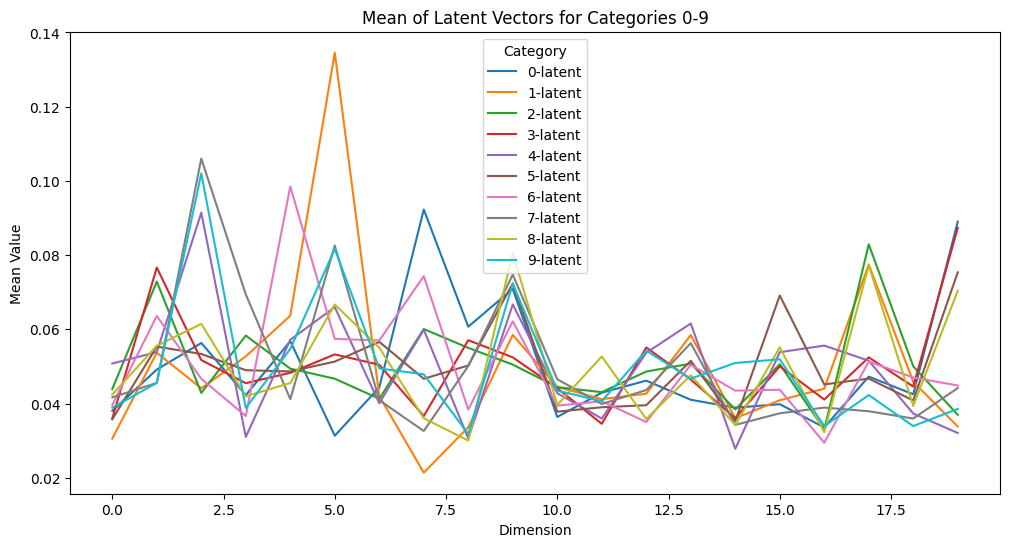

In [9]:
# 시각화
plt.figure(figsize=(12, 6))
for i in DIGITS:
    plt.plot(data_dict[f'{i}_latent'].mean(axis=0), label=f"{i}-latent")

plt.title("Mean of Latent Vectors for Categories 0-9")
plt.xlabel("Dimension")
plt.ylabel("Mean Value")
plt.legend(title="Category")
plt.show()